# Synthesis Assignment (100)

# Group Information

Use the form fields below to input your group number and group member information.

In [1]:
# @title Group Number { run: "auto" }
groups = list(range(1,23))
Group_Number = 10 # @param [groups] {type:"integer"}
print('Group Number:', Group_Number)

Group Number: 10


In [2]:
# @title Group Member Full Names { run: "auto" }
Group_Member_1 = 'Murtaza Bin Farooq' # @param {type:"string", placeholder:"Enter Full Name 1"}
Group_Member_2 = 'Vivek Parmar' # @param {type:"string", placeholder:"Enter Full Name 2"}
Group_Member_3 = 'Sheikh Sahil Mobin' # @param {type:"string", placeholder:"Enter Full Name 3"}
Group_Member_4 = 'Sheikh Md Faysal' # @param {type:"string", placeholder:"Enter Full Name 4"}
Group_Member_5 = 'Rishitha Reddy Busi' # @param {type:"string", placeholder:"Enter Full Name 5"}
print('Group Members:')
print(Group_Member_1)
print(Group_Member_2)
print(Group_Member_3)
print(Group_Member_4)
print(Group_Member_5)

Group Members:
Murtaza Bin Farooq
Vivek Parmar
Sheikh Sahil Mobin
Sheikh Md Faysal
Rishitha Reddy Busi


# Directions
In the Synthesis Assignment, which will be submitted in two parts, your group will perform data mining to solve a real-world business problem. As a group, you will choose one of the following business problems and accompanying dataset.

<br>

| Business Problem (Prediction)| Dataset File Name |
| ----------- | ----------- |
| Income & Audit Success | [CompanyAudit.csv](https://github.com/CHill-MSU/INFO583/blob/main/CompanyAudit.csv)|
| Employee Salary & Retention| [EmployeeRetention.csv](https://github.com/CHill-MSU/INFO583/blob/main/EmployeeRetention.csv)|
| Loan Amount & Approval| [LoanApproval.csv](https://github.com/CHill-MSU/INFO583/blob/main/LoanApproval.csv)|
| Customer CLV & Marketing Campaign Success| [MarketingCampaign.csv](https://github.com/CHill-MSU/INFO583/blob/main/MarketingCampaign.csv)|
| Telecom Customer CLV & Churn | [TeleChurn.csv](https://github.com/CHill-MSU/INFO583/blob/main/TeleChurn.csv)|

<br>

First, type your group number and group member names in the text cells above. You will include all prerequisite code necessary for your code in Parts 1 and 2 to run in the [Prerequisite Code](#scrollTo=1NApcFUYjX8g) Section below.

Rename this template file - <b>INFO583_SA_Group#.ipynb</b>, where # is the group number. As an example, Group 1's SA submission would be named **INFO583_SA_Group1.ipynb**.

<br>

> 1.   ***The link to your Google Colab notebook file***: Submit the link to your notebook file. To do so, click **Share** on the top right-hand side. Then a box will pop-up. You need to change **"restricted"** to **"anyone with the link."** Then, copy the link and paste it as a comment when submitting the assignment on Canvas.
> 2.   ***The IPYNB notebook file***: Download the same file as ipynb. To do so, Go to **File**, select **Download**. Then Click on **ipynb** on the menu box.
> 3.   ***The PDF version of your notebook file***: Download the same file as pdf. To do so, Go to **File**, select **Print**,A menu box will pop up. Then Click on **PDF** on the menu box. This will convert the file into a PDF file, instead of printing it using a printer.

All written responses must be in your own words. If using AI in any capacity to aid with written responses to assignment question prompts,  there is 1 additional required deliverable for the assignment.
> 1.   ***A PDF of all AI prompts and responses used***: Submit this information aggregated as a PDF.

If this is not included and responses appear to be AI generated you will receive a 0 for the assignment. If this is included and your written responses are plagiarized, you will receive a 0 for the assignment.

**Note**: Points will be deducted for extraneous code in the submissions, inefficient code, incorrect file naming, and if your answers are not in the space provided for answers.

**Overview:**

<br>

**Part 1**

In Part 1, you will define the business problem, cleanse and preprocess the data, perform exploratory data analysis, and perform linear regression analysis. To complete Part 1, you will fill in the required information in the [Part 1](#scrollTo=cwyEfhMwUTT1) Section.

<br>

**Part 2**

In Part 2, you will perform predictive analysis, evaluate your predictive models, and make recommendations and discuss your results within the context of the business problem. To complete Part 2, you will include all required information for Part 1 and fill in the required information in the [Part 2](#scrollTo=8fZ_eKishBVo) Section.


<hr>
<br>

# Prerequisite Code

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pylab as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer,
    FunctionTransformer, OneHotEncoder, OrdinalEncoder)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    recall_score, precision_score, roc_auc_score, f1_score,
    pairwise, silhouette_samples, silhouette_score,
    adjusted_rand_score, v_measure_score,
    PredictionErrorDisplay, ConfusionMatrixDisplay)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse, mse, meanabs
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
set_config(transform_output="pandas")

# Part 1 (50)

## Directions

Include your code and any required written information immediately under the relevant sections or prompts in the space provided.

You will submit your code and written responses in this .ipynb template notebook in the space provided under the sectioned prompts. Under the prompts there are code and/or text cells provided. If additional cells are needed, add the cells under the appropriate heading.

Your code and written responses should be easy for someone who did not write the code or perform the analysis to follow. Points will be deducted for extraneous code or if file naming instructions are not followed.

**Note:** Your Part 1 submission will only include responses for Part 1. Part 2 should remain blank or hidden in the Part 1 submission.

<br>

**Points:** 50

<br>






## 1.1 Problem Definition & Statement (10)

**1.1 A (5) First, use the code cell below to identify your group's selected dataset and the numerical target variable (column name) that will be used in Part 1 for linear regression analysis and the categorical target variable that will be used in Part 2 for classification analysis.**

In [4]:
# @title Identify Problem/Dataset

Dataset = 'LoanApproval.csv' # @param ["CompanyAudit.csv", "CCDefault.csv", "CustomerChurn.csv", "EmployeeRetention.csv", "LoanApproval.csv", "MarketingCampaign.csv"]
Numerical_Target_Variable = 'loan_amount' # @param {type:"string"}
Categorical_Target_Variable = 'loan_status' # @param {type:"string"}

print(Dataset)
print(Numerical_Target_Variable)
print(Categorical_Target_Variable)


LoanApproval.csv
loan_amount
loan_status


In [5]:
data = pd.read_csv('LoanApproval.csv') # read CSV file
data.set_index('loan_id', inplace = True)

**1.1 B (5) Next, use the text cell below for your problem definition and statement.**

**The problem statement should discuss the following: what is the problem and who it affects, financial/social implications of having a solution to the problem, how the model would be used in practice, and the acceptable level of model performance.**


Loan approval processes are critical, yet often complex decisions made by financial institutions. Applicants submit personal and financial information, hoping to secure funding for homes, education, businesses, or emergencies. However, manual evaluation is time-consuming, prone to bias, and inconsistent across loan officers. Here, with our following dataset we will take the previous loan approval data and make a prediction model which can optimize the approvals for the customers. As a result it will reduce the default rates and accelerate the decision-making process. We will be doing this project in two parts.

<hr>
<br>

## 1.2 Data: Cleansing and Preprocessing (10)


**1.2 A (5) Use the code cell below (and add any additional cells, as necessary) to cleanse and preprocess the data that you will use in your analysis.**

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4269 entries, 1 to 4269
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1   education                  4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 433.6+ KB


In [7]:
any(data.index.duplicated())

False

In [8]:
data.columns = data.columns.str.strip()

In [9]:
target= ['loan_amount']
class_target= ['loan_status']
numerical_var = ['no_of_dependents','income_annum','loan_term','cibil_score','residential_assets_value','commercial_assets_value','luxury_assets_value','bank_asset_value']
ordinal_var = ['education']
nominal_var= list(data.columns.difference(numerical_var + ordinal_var + target + class_target))
data[nominal_var + ordinal_var + class_target] = data[nominal_var + ordinal_var + class_target].astype('category')
data[numerical_var] = data[numerical_var].apply(pd.to_numeric, errors = 'coerce')
print('Variables by Type')
print('Numerical:', numerical_var)
print('Nominal:', nominal_var)
print('Ordinal:', ordinal_var)

Variables by Type
Numerical: ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Nominal: ['self_employed']
Ordinal: ['education']


In [10]:
# defining the target variable as y
y = data[target]
X = data.drop(target + ['loan_status'], axis=1)
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=123)

In [11]:
# creating the data pipepline  for numerical , ordinal , nominal columns
# for numerical
numerical_var_trans = Pipeline(steps = [("standard_scaler", StandardScaler())])
numerical_features = numerical_var
# for ordinal variable
ordinal_var_trans = Pipeline(steps=[("ordinal_enco", OrdinalEncoder(categories='auto'))])
# for nominal
nominal_var_trans = Pipeline(steps= [("ordinal_OHC", OneHotEncoder(sparse_output= False, handle_unknown= 'ignore',drop='first'))])
# using columns transformr
# Here we have created three pipelines as one has only noms & ords, the full_pp has nums, and full_L_pp has no scaler for regression. This gives us option to keep nums in original form while fitting PP to others.
full_pp = ColumnTransformer(transformers=[("ords",ordinal_var_trans,ordinal_var),
                                     ('nums', 'passthrough', numerical_features),
                                     ("noms",nominal_var_trans,nominal_var)], remainder='drop')
# half pipeline
half_pp = ColumnTransformer(transformers=[("ords",ordinal_var_trans,ordinal_var),
                                          ("noms",nominal_var_trans,nominal_var)])
ord_pp = ColumnTransformer(transformers=[("ords",ordinal_var_trans,ordinal_var)])

**1.2 B (5) In the text cell below, briefly describe and discuss (in paragraph format) the cleansing and preprocessing steps taken to prepare the data for analysis.**

In the preprocessing stage, we began by examining the dataset structure and summary information. No missing values were identified, and no duplicate records were found. Next, we organized the variables into three categories: numerical, ordinal, and nominal. The target variable was also separated for clarity. Following this, the dataset was split into training and testing subsets for modeling purposes(70/30). Also we implemented preprocessing pipelines, allowing these transformations to be applied flexibly as needed during the modeling process.



---



## 1.3 Data: Description & EDA (15)





**1.3 A (8) Use the code cell below (and add any additional cells, as necessary) to describe the data and perform exploratory data analysis (EDA).**

**Description and EDA of the dataset should include: dataset overview, preview, dimensionality, visualization, descriptive statistics. Can also include Cluster Analysis.**

In [12]:
data[numerical_var].describe()

,no_of_dependents,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [13]:
ord_nom_trans = half_pp.fit_transform(data[nominal_var + ordinal_var])
ord_nom_trans.describe().T

,count,mean,std,min,25%,50%,75%,max
ords__education,4269.0,0.497775,0.500054,0.0,0.0,0.0,1.0,1.0
noms__self_employed_ Yes,4269.0,0.503631,0.500045,0.0,0.0,1.0,1.0,1.0


In [14]:
data[numerical_var].corr()

,no_of_dependents,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.007266,1.000000,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_term,-0.020111,0.011488,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,-0.009998,-0.023034,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.007376,0.636841,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,-0.001531,0.640328,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,0.002817,0.929145,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.011163,0.851093,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000


In [15]:
data[target].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0


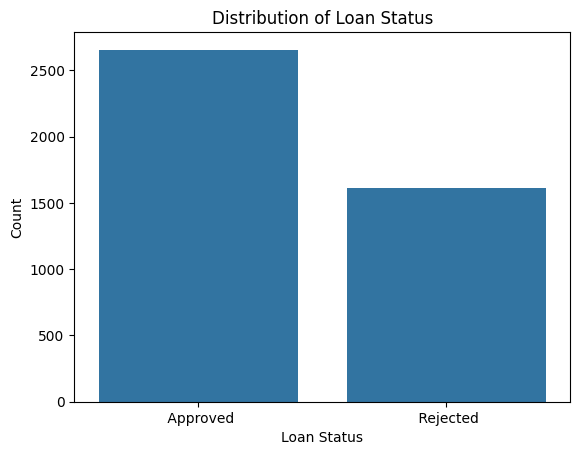

In [16]:
sns.countplot(x='loan_status', data=data)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status')
plt.show()

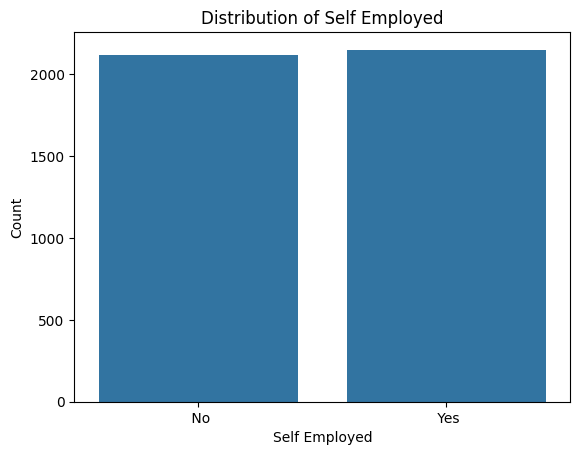

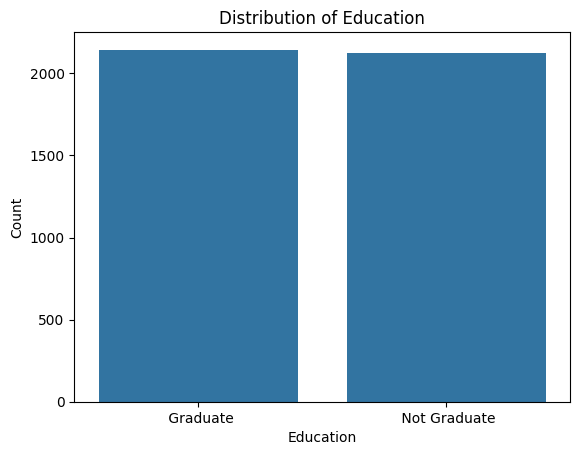

In [17]:
sns.countplot(x='self_employed', data=data)
plt.xlabel('Self Employed')
plt.ylabel('Count')
plt.title('Distribution of Self Employed')
plt.show()
sns.countplot(x='education', data=data)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Distribution of Education')
plt.show()


array([[<Axes: title={'center': 'loan_amount'}>]], dtype=object)

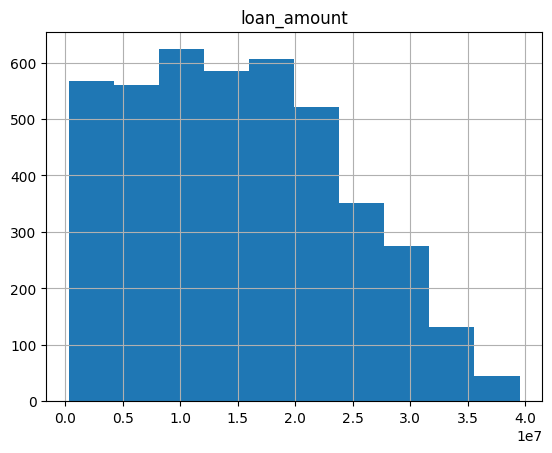

In [18]:
data[target].hist()

array([[<Axes: title={'center': 'no_of_dependents'}>,
        <Axes: title={'center': 'income_annum'}>,
        <Axes: title={'center': 'loan_term'}>],
       [<Axes: title={'center': 'cibil_score'}>,
        <Axes: title={'center': 'residential_assets_value'}>,
        <Axes: title={'center': 'commercial_assets_value'}>],
       [<Axes: title={'center': 'luxury_assets_value'}>,
        <Axes: title={'center': 'bank_asset_value'}>, <Axes: >]],
      dtype=object)

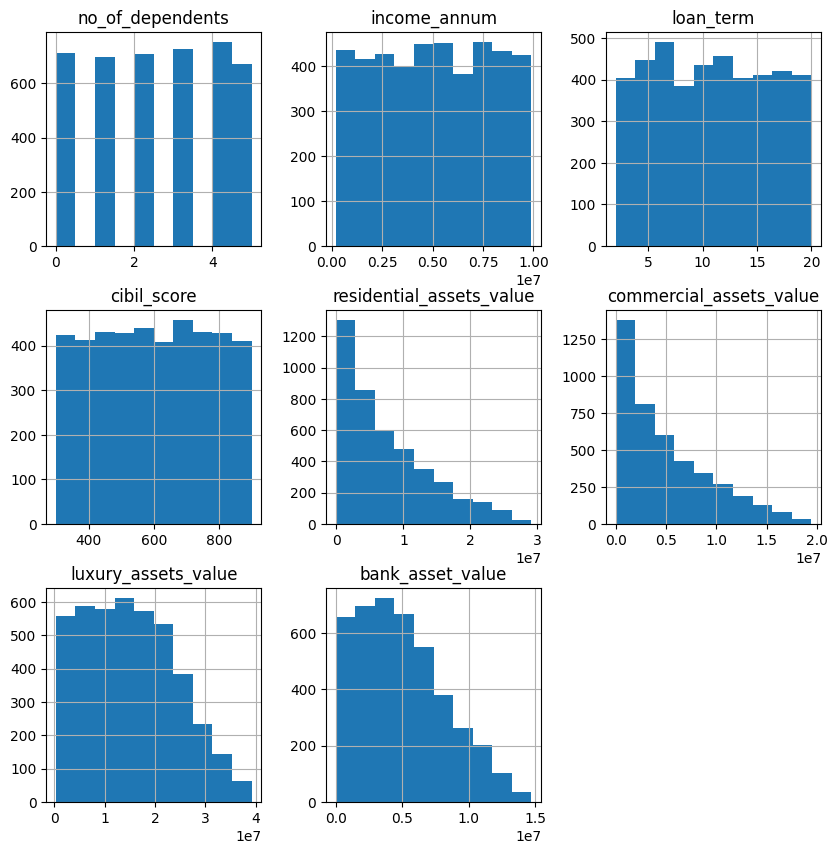

In [19]:
data[numerical_var].hist(figsize=(10,10))

<Axes: xlabel='income_annum', ylabel='loan_amount'>

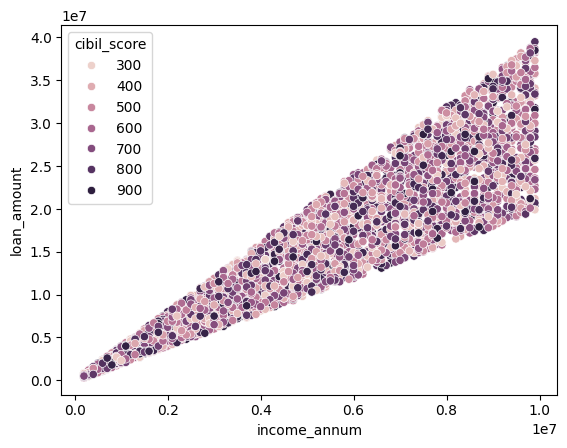

In [20]:
sns.scatterplot(data=data, x='income_annum', y='loan_amount', hue='cibil_score')

<Axes: xlabel='loan_status', ylabel='cibil_score'>

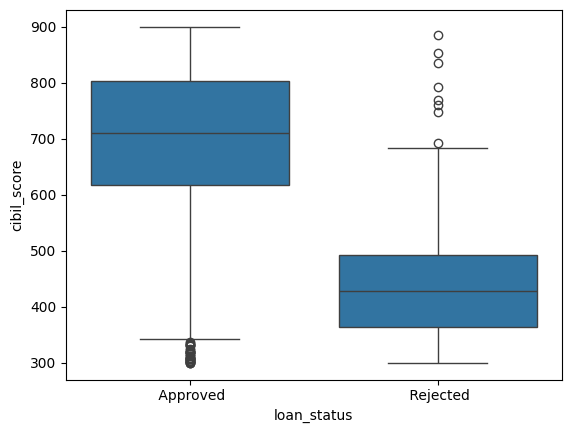

In [21]:
sns.boxplot(data=data, x='loan_status', y='cibil_score')

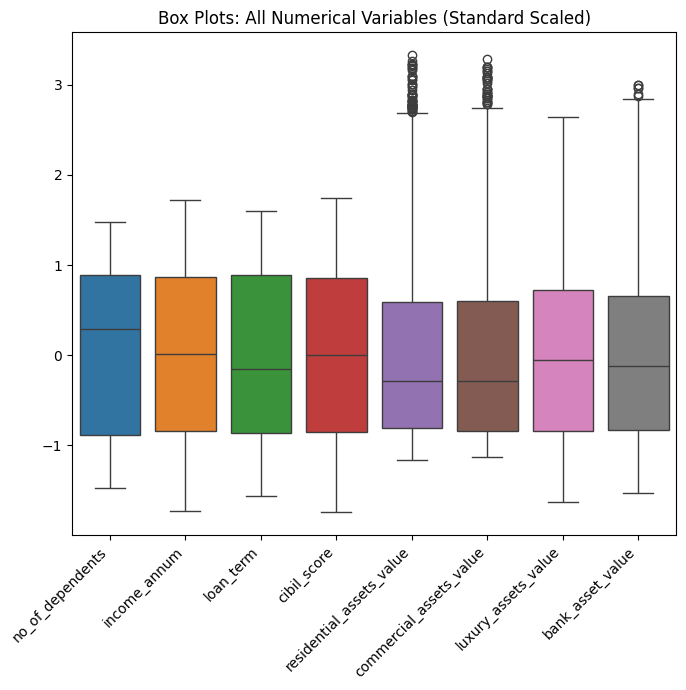

In [22]:
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(data[numerical_var].copy())
scaled_nums_df = pd.DataFrame(scaled_nums, columns=numerical_var, index=data.index)

plt.figure(figsize=(7, 7))
sns.boxplot(data=scaled_nums_df)
plt.title('Box Plots: All Numerical Variables (Standard Scaled)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cluster Analysis

In [23]:
holdout_var = data['loan_status']
input_var = data.drop('loan_status',axis=1)

In [24]:
input_var_processed = full_pp.fit_transform(input_var)
comp = linkage(input_var_processed, method='complete')

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


<Axes: title={'center': 'WSS Elbow Plot'}, xlabel='k', ylabel='WSS'>

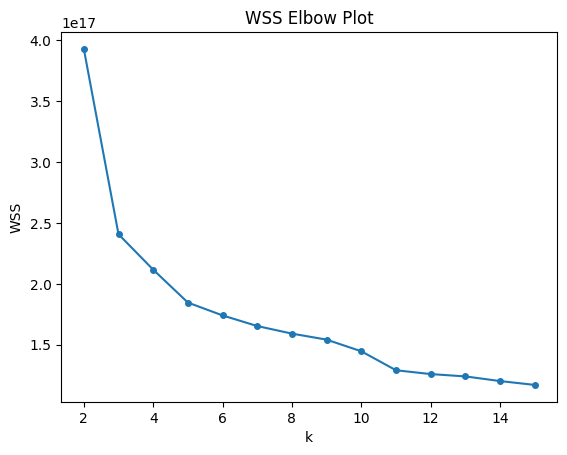

In [25]:
max_k = 15
search_k = list(range(2,max_k+1,1))
search_k

wss = []
for n_clusters in search_k:
  culster_labels = fcluster(comp,n_clusters,criterion='maxclust')
  wss.append(np.sum([np.sum((input_var_processed[culster_labels==i] - np.mean(input_var_processed[culster_labels==i], axis=0))**2) for i in range(1,n_clusters+1)]))
k_wss = pd.DataFrame(zip(search_k,wss),columns = ['k','wss'])
k_plot_wss = k_wss.plot(x='k',
                        y='wss',
                        marker = 'o',
                       markersize = 4,
                        legend = False,
                        ylabel = 'WSS',
                        title = "WSS Elbow Plot")
k_plot_wss

In [26]:
# cluster assignment
chosen_k = 5
memb_comp =  fcluster(comp,chosen_k,criterion='maxclust')
wss_hca =  k_wss.loc[k_wss['k'] == chosen_k,'wss'].iloc[0]
sil_score = silhouette_score(input_var_processed,memb_comp)
ari_hca = adjusted_rand_score(holdout_var,memb_comp)
print('Cophenetic Correlation:  ', cophenet(comp,pdist(input_var_processed))[0])
print("Silhouette Score:        ", sil_score)
print("Adjusted Random Score:   ", ari_hca)

Cophenetic Correlation:   0.7091839660354488
Silhouette Score:         0.2925635066947706
Adjusted Random Score:    0.0010204969679365938


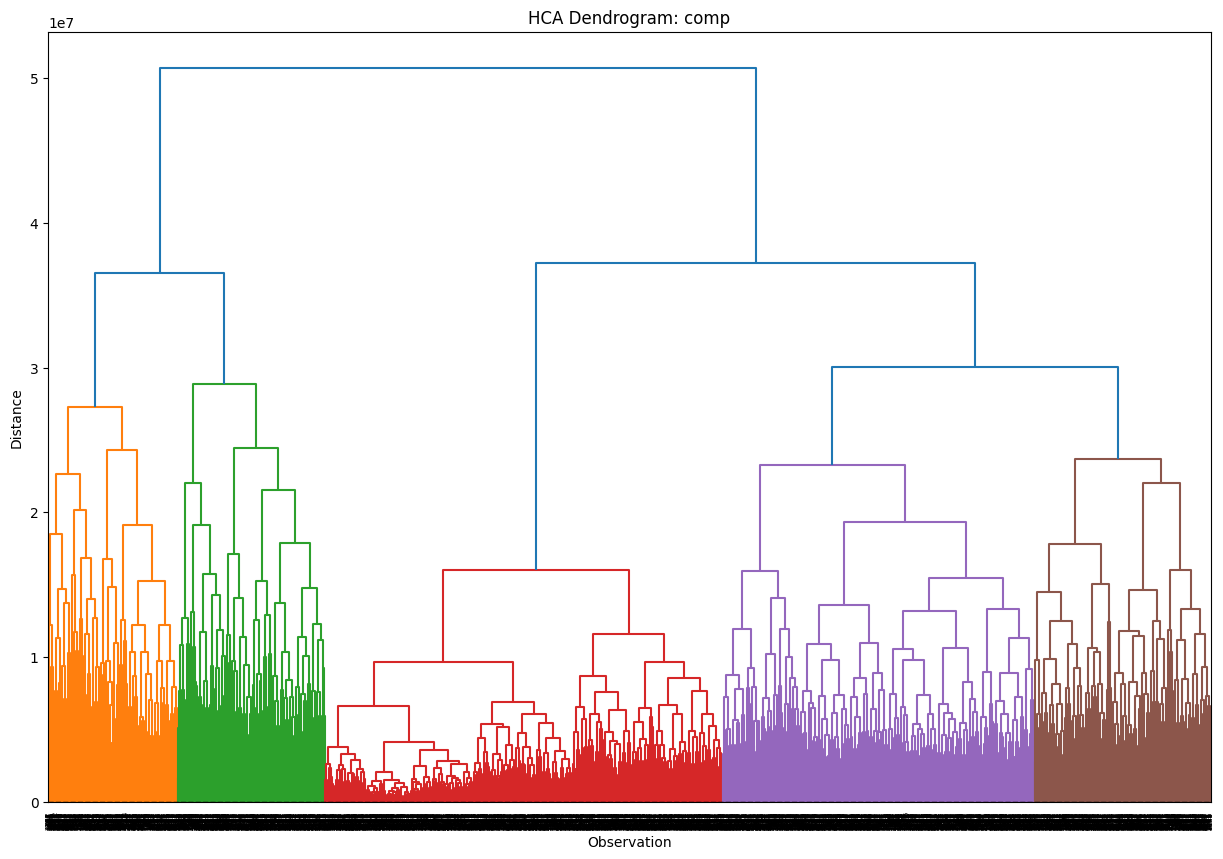

In [27]:
fig = plt.figure(figsize = (15, 10))
plt.title('HCA Dendrogram: comp')
plt.xlabel('Observation')
plt.ylabel('Distance')
dendrogram(comp,
           color_threshold = 30000000)
plt.axhline(y = chosen_k,
            linestyle = 'dashed',
            color = 'black',
            linewidth = 1.0,)
plt.show()

In [28]:
data_clus = data.copy()
data_clus['hca_clusters'] = memb_comp
data_clus['hca_clusters'].value_counts()
cluster_group = data_clus.drop(nominal_var + ordinal_var + class_target, axis =1).groupby('hca_clusters')
print(round(cluster_group.mean(),2))

              no_of_dependents  income_annum  loan_amount  loan_term  \
hca_clusters                                                           
1                         2.53    8417190.78  25198951.78      11.12   
2                         2.53    8297777.78  25074444.44      10.91   
3                         2.45    1922655.72   5734360.03      10.93   
4                         2.55    5026963.35  15096771.38      10.90   
5                         2.46    7025891.47  20722170.54      10.67   

              cibil_score  residential_assets_value  commercial_assets_value  \
hca_clusters                                                                   
1                  596.21               10251362.68               8124109.01   
2                  595.37               19714259.26               9514629.63   
3                  606.83                2621081.45               1646680.36   
4                  598.52                8079319.37               4504712.04   
5              

In [29]:
max_k = 15
search_k = list(range(2,max_k+1,1))
search_k

WSS_km = []

for n_clusters in search_k:
   km = KMeans(n_clusters = n_clusters, random_state = 123, n_init=10)
   km = km.fit(input_var_processed)
   WSS_km.append(km.inertia_)

<Axes: title={'center': 'WSS Elbow Plot'}, xlabel='k', ylabel='WSS'>

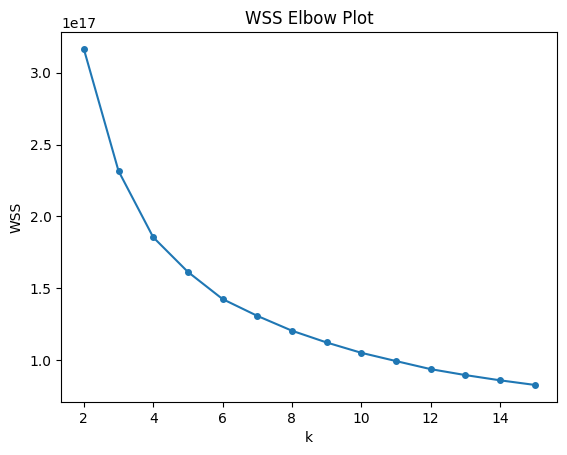

In [30]:
k_WSS_km = pd.DataFrame(zip(search_k, WSS_km), columns = ['k', 'WSS'])
k_plot_WSS_km = k_WSS_km.plot(x = 'k',
                        y = 'WSS',
                        marker = 'o',
                        markersize = 4,
                        legend = False,
                        ylabel = 'WSS',
                        title = 'WSS Elbow Plot')
k_plot_WSS_km

In [31]:
chosen_k_KM = 5 # identify chosen k value
WSS_KM = k_WSS_km.loc[k_WSS_km['k'] == chosen_k_KM, 'WSS'].iloc[0]

In [32]:
kmeans = KMeans(n_clusters = chosen_k_KM, random_state = 123).fit(input_var_processed)
Sil_KM = silhouette_score(input_var_processed, kmeans.predict(input_var_processed))
ARI_KM = adjusted_rand_score(holdout_var, kmeans.predict(input_var_processed))
print('WSS:', WSS_KM, 'Silhouette:', Sil_KM, 'ARI:', ARI_KM)
print('Cophenetic Correlation:  ', cophenet(comp,pdist(input_var_processed))[0])

WSS: 1.6147480210195232e+17 Silhouette: 0.32908495185312064 ARI: 0.000721755541947819
Cophenetic Correlation:   0.7091839660354488


In [33]:
np.unique(kmeans.labels_, return_counts = True)
data.index[kmeans.labels_ == 4]

Index([   6,   11,   13,   16,   25,   38,   39,   47,   48,   53,
       ...
       4231, 4232, 4236, 4246, 4248, 4249, 4253, 4256, 4266, 4268],
      dtype='int64', name='loan_id', length=1222)

In [34]:
centroids = pd.DataFrame(kmeans.cluster_centers_,
                         columns = input_var_processed.columns)
print(round(centroids,2))

   ords__education  nums__no_of_dependents  nums__income_annum  \
0             0.49                    2.60          6759493.67   
1             0.50                    2.45          1602406.64   
2             0.49                    2.42          8719238.90   
3             0.50                    2.49          7910975.61   
4             0.50                    2.52          4531617.65   

   nums__loan_term  nums__cibil_score  nums__residential_assets_value  \
0            10.90             593.47                     13644163.15   
1            10.91             608.14                      2156348.55   
2            11.21             600.16                     19824101.48   
3            10.72             595.31                      5089329.27   
4            10.87             598.01                      5625653.59   

   nums__commercial_assets_value  nums__luxury_assets_value  \
0                     6257383.97                18974542.90   
1                     1438008.30      

In [35]:
print('HCA, Complete Linkage', 'WSS:', wss_hca, 'Silhouette:', sil_score, 'ARI:', ari_hca)
print('k-Means' , 'WSS:', WSS_KM, 'Silhouette:', Sil_KM, 'ARI:', ARI_KM)

HCA, Complete Linkage WSS: 1.8465361290981578e+17 Silhouette: 0.2925635066947706 ARI: 0.0010204969679365938
k-Means WSS: 1.6147480210195232e+17 Silhouette: 0.32908495185312064 ARI: 0.000721755541947819


**1.3 B (7) In the text cell below, describe (in paragraph format) the dataset and any important findings from your description and EDA. A discussion of class imbalance should also be included, if present, and strategies for handling any imbalance should be included.**

In our exploratory data analysis EDA, we began with descriptive statistics for all variables followed by correlation analysis to understand their relationships. Visualizations were then created for key variables to provide deeper insights. The bar plot of the categorical variable Loan_Status revealed a clear class imbalance, with fewer rejected loans compared to approved ones. To address this imbalance, we plan to apply undersampling techniques in Part 2 of our project to ensure a more efficient and fair classification model. The distributions of Education and Self_Employed showed no significant dominance of any category, indicating a fairly balanced spread across these groups. Our target variable, loan amount, exhibited a right-skewed distribution, with most applicants requesting higher loans. Scatter plots comparing Income_Annum and loan amount highlighted that higher income individuals tend to apply for higher loan amounts, while credit score appeared more evenly distributed. However, boxplots demonstrated that applicants with higher credit scores had a greater likelihood of approval, though notable outliers were present across variables, particularly in assets. Finally, we performed cluster analysis using both Hierarchical Clustering (HCA) and K-Means. The results showed that K-Means provided stronger clustering performance (WSS: 1.6147480210195232e+17 Silhouette: 0.32908495185312064 ARI: 0.000721755541947819) compared to HCA (WSS: 1.8465361290981578e+17 Silhouette: 0.2925635066947706 ARI: 0.0010204969679365938). Based on these metrics, K-Means is the preferred clustering approach for this dataset, as it yields better compactness and separation among clusters.

## 1.4 Linear Regression Analysis (15)

**1.4 A (5) Perform Linear Regression Analysis to predict the numerical target variable identified in Question 1.1A. You should include regression coefficients as output.**

**NOTE: Do not include the categorical target variable as a predictor variable in your model.**


In [36]:
# fitting the model
lm_results = sm.OLS(y_train, sm.add_constant(full_pp.fit_transform(X_train))).fit()
print(lm_results.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_amount   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     1812.
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:01:19   Log-Likelihood:                -49178.
No. Observations:                2988   AIC:                         9.838e+04
Df Residuals:                    2977   BIC:                         9.844e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [37]:
train_res = pd.DataFrame({'actual': lm_results.model.endog, # actual y values
                          'fitted': lm_results.fittedvalues, # fitted values (predictions)
                          'residuals': lm_results.resid, # model errors
                          'std_residuals': np.sqrt(np.abs(lm_results.get_influence().resid_studentized_internal))})

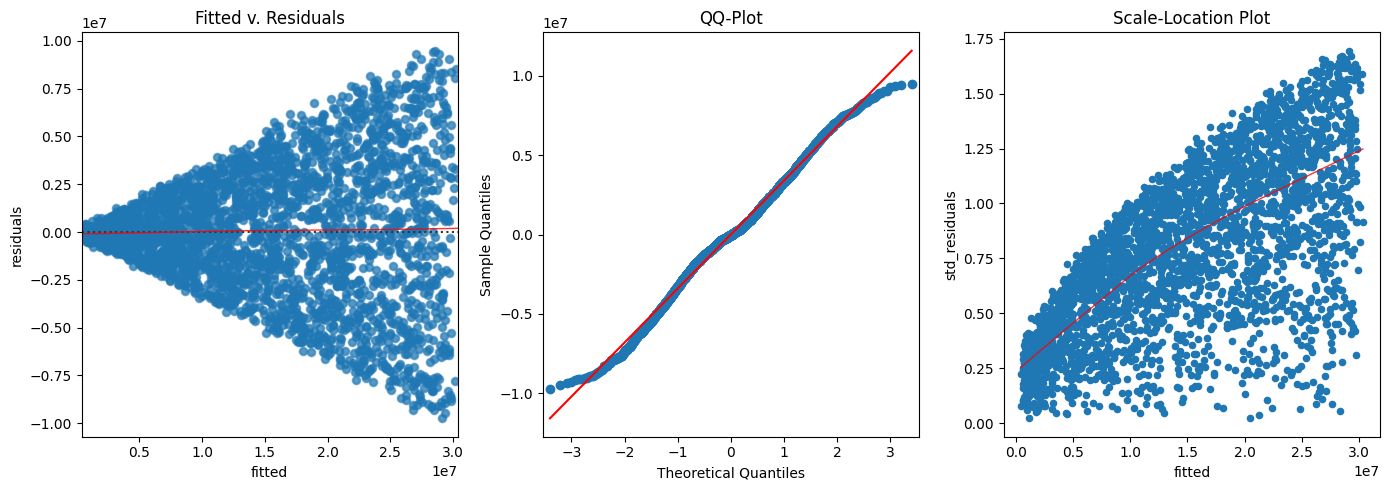

In [38]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize=(14,5)) # output 3 plots in one row
# residual plot
res_plot = train_res.plot.scatter(x = 'fitted', y = 'residuals', alpha=0.5, title = 'Fitted v. Residuals', ax = axes[0])
sns.residplot(x = train_res.fitted, y = train_res.residuals, lowess = True, scatter_kws = {'alpha': 0.5}, line_kws = {'color': 'red', 'lw': 1, 'alpha': 0.8}, ax = axes[0])
# qq plot
qq_plot = sm.qqplot(train_res['residuals'], line = "s", ax = axes[1])
qq_plot.axes[1].set_title('QQ-Plot')
# scale-location plot
scale_loc = train_res.plot.scatter(x = 'fitted', y = 'std_residuals', title = 'Scale-Location Plot', ax = axes[2])
sns.regplot(x = train_res.fitted, y = train_res.std_residuals, scatter = False, ci = False, lowess = True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax = axes[2])
plt.tight_layout() # ensure plot fit
plt.show() # output plots

In [39]:
# Defining the Trainnig pipeline
pipe = Pipeline(steps = [("preprcess", full_pp),
                         ("linreg", LinearRegression())])

pipe.fit(X_train,y_train)

Pipeline(steps=[('preprcess',
                 ColumnTransformer(transformers=[('ords',
                                                  Pipeline(steps=[('ordinal_enco',
                                                                   OrdinalEncoder())]),
                                                  ['education']),
                                                 ('nums', 'passthrough',
                                                  ['no_of_dependents',
                                                   'income_annum', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('noms',
                                                  Pipeline(steps=[('ordinal_OHC',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['self_employed'])])),
                ('linreg', LinearRegression())])

In [40]:
lm_coefs = pd.DataFrame(pipe.named_steps["linreg"].coef_.T,
                        columns = ['Coefficients'],
                        index = pipe.named_steps['linreg'].feature_names_in_)
print('Intercept          ', pipe.named_steps['linreg'].intercept_)
print(lm_coefs)

Intercept           [173770.06543742]
                                Coefficients
ords__education                 10883.388711
nums__no_of_dependents         -57995.731818
nums__income_annum                  3.019180
nums__loan_term                 -9746.542864
nums__cibil_score                 251.880740
nums__residential_assets_value      0.006422
nums__commercial_assets_value       0.046325
nums__luxury_assets_value          -0.014075
nums__bank_asset_value             -0.037494
noms__self_employed_ Yes       -93990.580048


**1.4 B (5) Interpret your model and evaluate model performance.**

In [41]:
test_pred = pipe.predict(X_test)
print("R2 ", r2_score(y_test, test_pred))
print("MAE ", mean_absolute_error(y_test, test_pred))
print("RMSE ", root_mean_squared_error(y_test, test_pred))

R2  0.8637181468617459
MAE  2525385.914185755
RMSE  3327346.317529302


The OLS regression model explains about 86% of the variance in loan amount R² = 0.864, indicating strong explanatory power. Among all predictors, annual income and commercial assets value are statistically significant and have the largest positive effects on loan amount, making them the main drivers of loan approvals. Other predictors, such as education level, dependents, CIBIL score, and employment type, are not statistically significant and contribute little explanatory power.
In terms of predictive performance, the model shows a Mean Absolute Error 2.53M and a Root Mean Squared Error 33,3M, meaning the average prediction error is around 16–20% of the typical loan size. While reasonably good, the RMSE being larger than MAE suggests the presence of outliers or uneven error distribution.
Overall, the model performs well in prediction but is mainly driven by two strong predictors, with some assumption violations that limit reliability for inference.

**1.4 C (2.5) Is this a good model to predict your target variable? Why or why not? Explain.**

Yes, this is a reasonably good model for prediction of loan amount because it achieves a high R²= 0.864 and relatively low prediction errors MAE = 2.53M, RMSE =3.33M. This means it can explain most of the variation in loan amounts and provides predictions that are fairly close to actual values.
In summary, while not perfect, this is a good baseline model for predicting loan approvals, and it provides a strong foundation to build upon for more advanced predictive systems that improve both customer access to credit and institutional risk management.



---

<br>



# Part 2 (50)

## Directions

Include your code and any required written information immediately under the relevant sections or prompts in the space provided.

You will submit your code and written responses in this .ipynb template notebook in the space provided under the sectioned prompts. Under the prompts there are code and/or text cells provided. If additional cells are needed, add the cells under the appropriate heading.

Your Synthesis Assignment Part 2 submission should include all Part 1 and Part 2 code and responses.

Your code and written responses should be easy for someone who did not write the code or perform the analysis to follow. Points will be deducted for extraneous code or if file naming instructions are not followed.

<br>

**Points:** 50






## 2.1 Classification Analysis (25)

**2.1 (25) Perform (at least) 4 types of classification analysis demonstrated in the course.**

**NOTE: Do not include the numerical target variable as a predictor variable in your models.**

In [42]:
y = data['loan_status']
X = data[numerical_var + nominal_var + ordinal_var]
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 123)

In [43]:
# Transformer to strip whitespace from strings
strip_whitespace = FunctionTransformer(lambda x: x.astype(str).str.strip(), validate=False)

class_nums_trans = Pipeline(steps = [("imputer_nums", SimpleImputer(strategy = "median"))])
class_noms_trans = Pipeline(steps = [("imputer_cats", SimpleImputer(strategy = "most_frequent")),
         ("encoder_nom", OneHotEncoder(sparse_output = False, drop = "if_binary",
                                       handle_unknown = "ignore"))])
ords_list = [[' Graduate', ' Not Graduate']]
class_ords_trans = Pipeline(steps = [('imputer_ords', SimpleImputer(strategy = "most_frequent")),
                                     ("encoder_ords", OrdinalEncoder(categories = ords_list))])
class_pp = ColumnTransformer(transformers = [("numeric", "passthrough", numerical_var), #Numerical variables passthrough
                                     ("nominal", class_noms_trans, nominal_var),
                                     ("ordinal", class_ords_trans, ordinal_var)],
                      verbose_feature_names_out = False)

##Decision Tree

In [44]:
pipe = Pipeline(steps = [("preprocess", class_pp),
 ("DT", DecisionTreeClassifier(random_state = 123, class_weight = 'balanced'))])

In [45]:
min_d = 2 # minimum max_depth
max_d = 10 # maximum max_depth
param_grid_dt = dict(DT__max_depth = list(range(min_d, max_d+1, 1)),
                  DT__min_samples_split = [2, 5, 10, 15],)
print(param_grid_dt)

{'DT__max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'DT__min_samples_split': [2, 5, 10, 15]}


In [46]:
grid_dt = GridSearchCV(pipe,
                    param_grid =  param_grid_dt,
                    scoring = 'accuracy',
                    cv = 5)
grid_dt.fit(X = train_X, y = train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         'passthrough',
                                                                         ['no_of_dependents',
                                                                          'income_annum',
                                                                          'loan_term',
                                                                          'cibil_score',
                                                                          'residential_assets_value',
                                                                          'commercial_assets_value',
                                                                          'luxury_assets_value',
                                                                          'bank_asset_value']),
                                                                        ('nominal',
                                                                         Pipeline(steps=[('imputer_cats',
                                                                                          SimpleImputer(strategy='most_freque...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder_ords',
                                                                                          OrdinalEncoder(categories=[[' '
                                                                                                                      'Graduate',
                                                                                                                      ' '
                                                                                                                      'Not '
                                                                                                                      'Graduate']]))]),
                                                                         ['education'])],
                                                          verbose_feature_names_out=False)),
                                       ('DT',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=123))]),
             param_grid={'DT__max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'DT__min_samples_split': [2, 5, 10, 15]},
             scoring='accuracy')

In [47]:
md_val = grid_dt.best_params_['DT__max_depth']
mss_val = grid_dt.best_params_['DT__min_samples_split']
print('best max depth:', md_val)
print('best min samples split:', mss_val)

best max depth: 6
best min samples split: 15


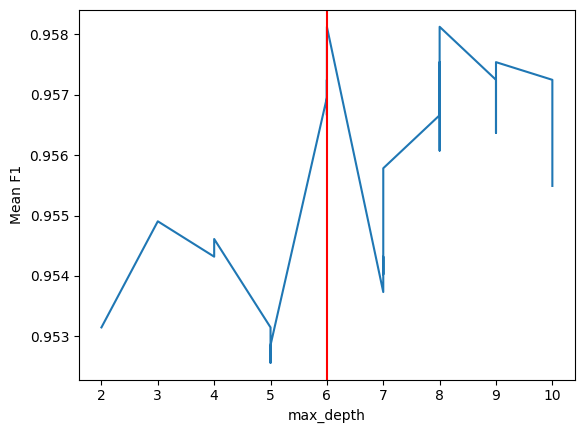

In [48]:
md_cva = pd.DataFrame(zip(grid_dt.cv_results_['param_DT__max_depth'].data,
                          grid_dt.cv_results_['param_DT__min_samples_split'].data,
                         grid_dt.cv_results_["mean_test_score"]),
                         columns = ['max_depth', 'min_samples_split','mean_F1'])
md_plot = md_cva.plot.line(x = 'max_depth',
                         y = 'mean_F1',
                         legend = False,
                         ylabel = 'Mean F1')
md_plot
md_plot.axvline(md_val, color = 'r')

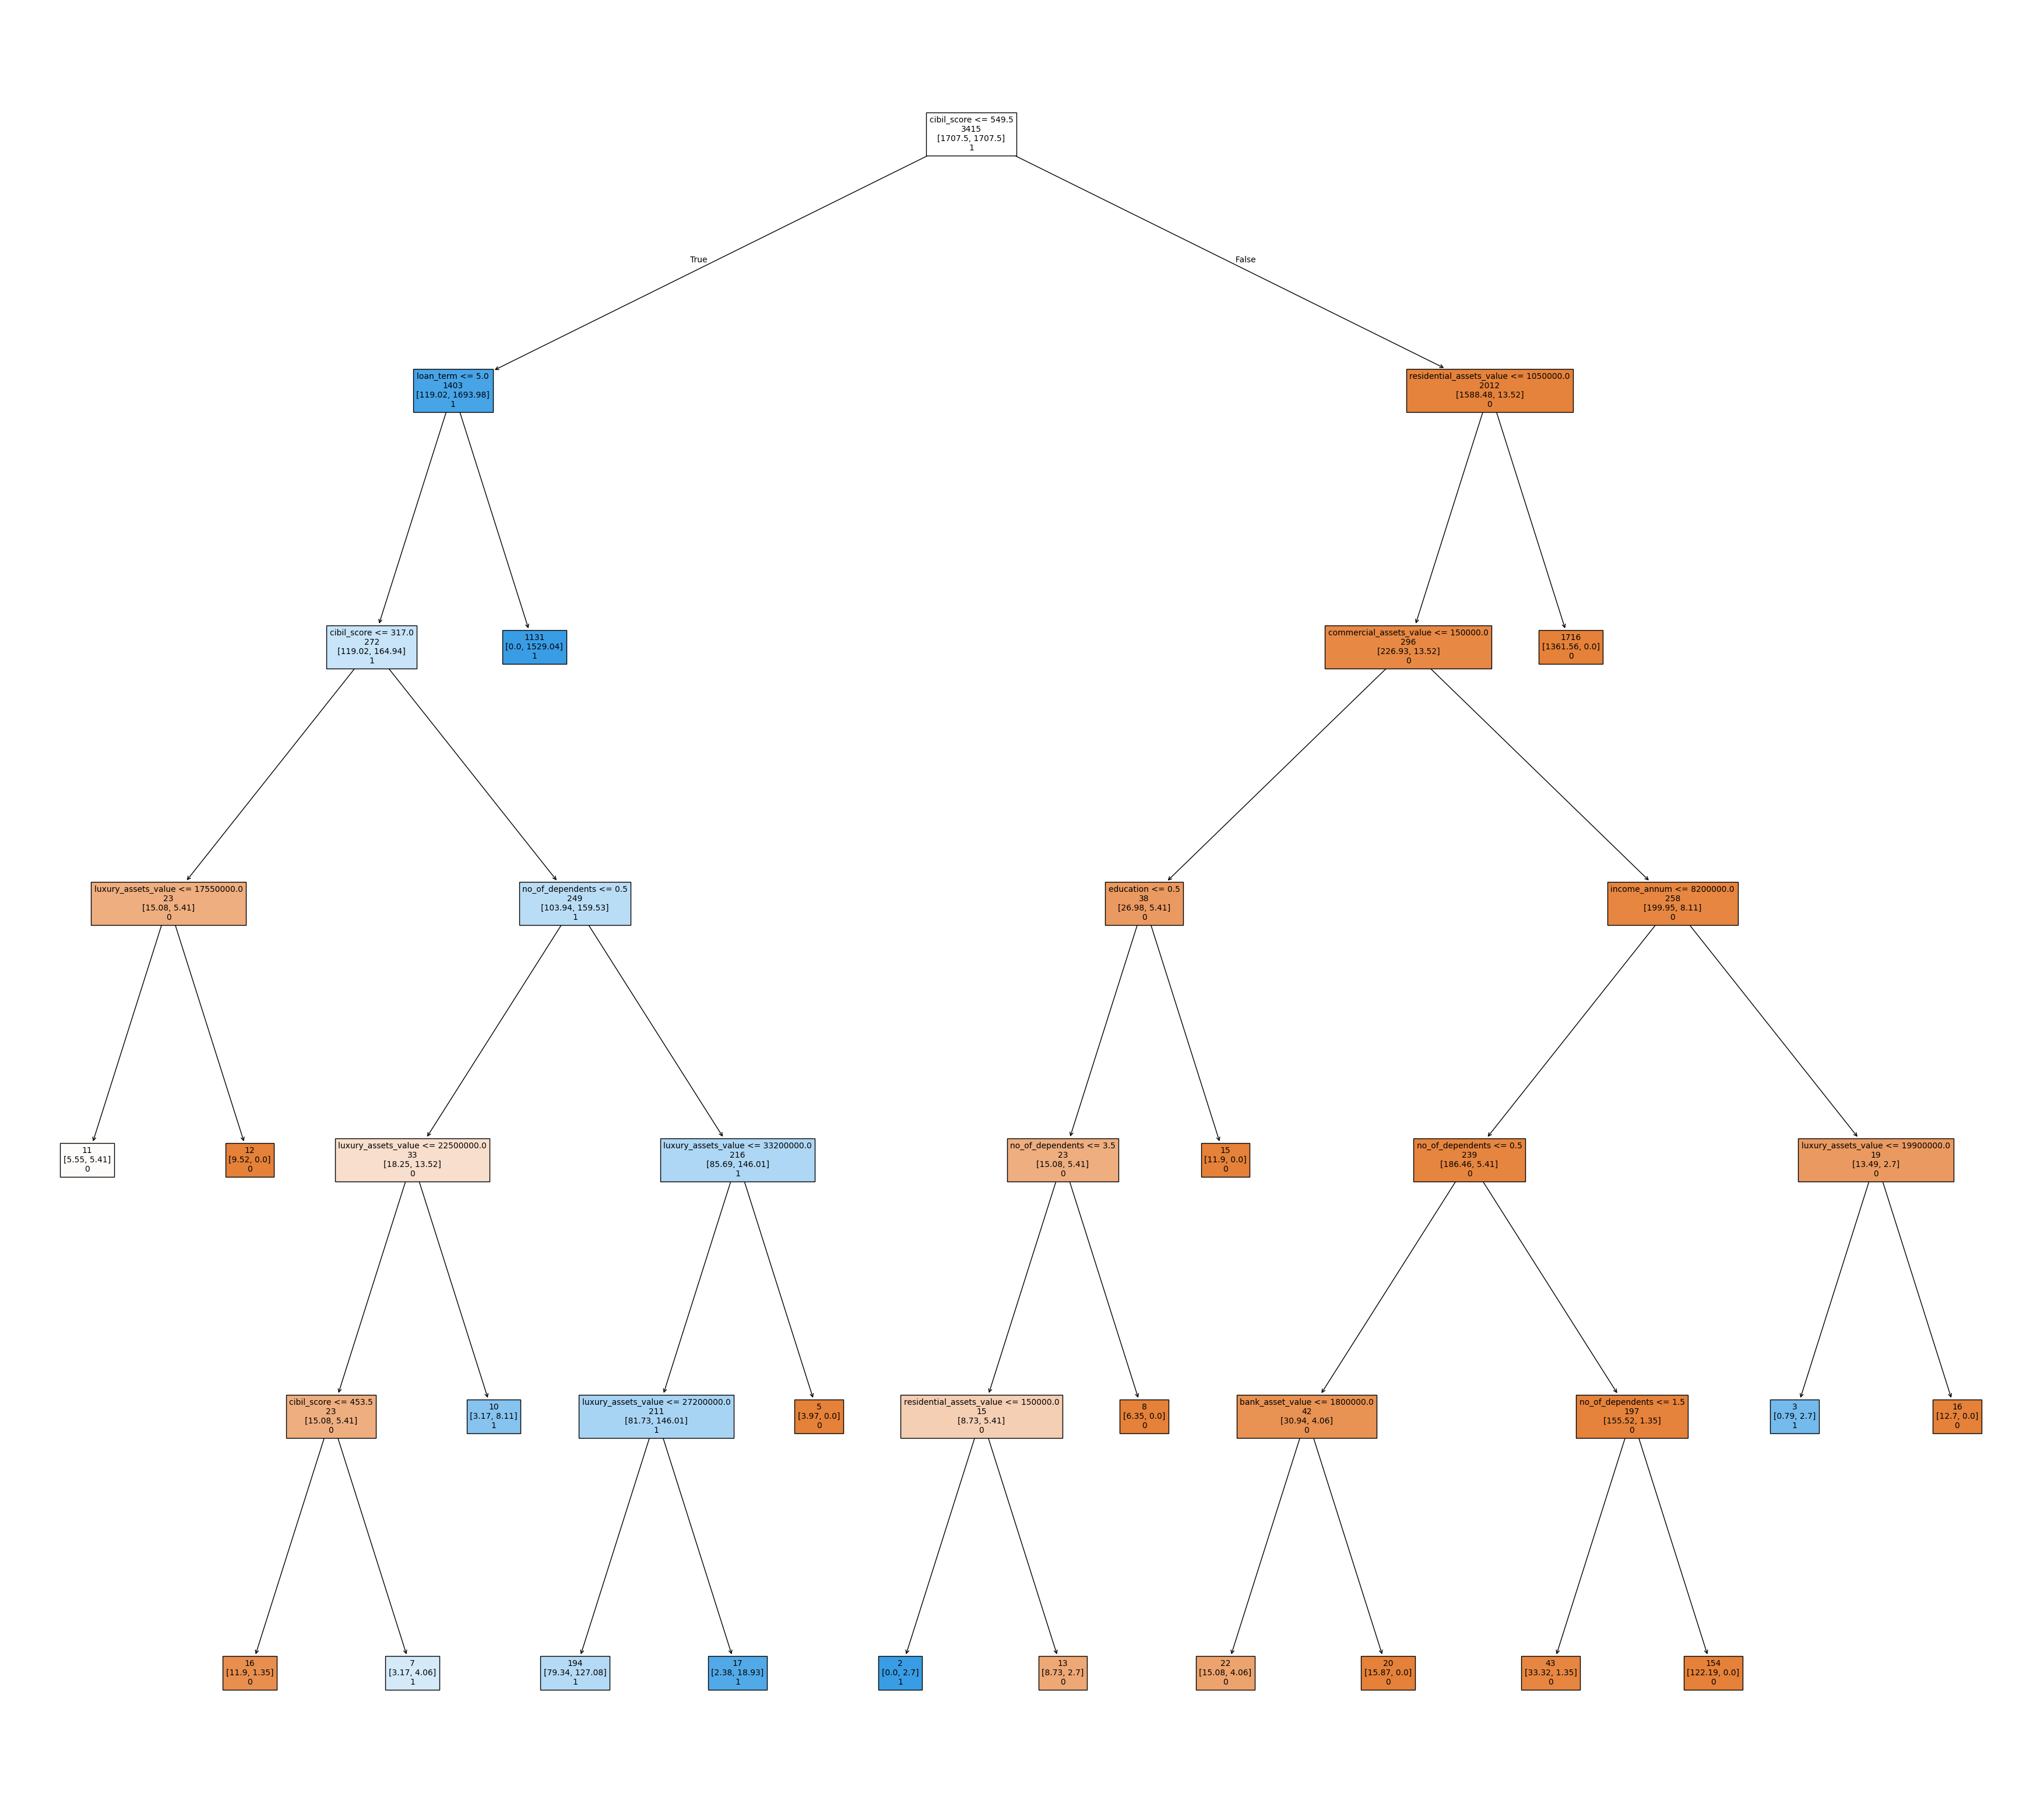

In [49]:
fig = plt.figure(figsize=(45, 40))
tree_plot = plot_tree(decision_tree = grid_dt.best_estimator_['DT'],
                      feature_names = grid_dt.best_estimator_['DT'].feature_names_in_,
                      proportion = False,
                      impurity = False,
                      class_names=['0', '1'],
                      filled = True,
                      label = 'none',
                      fontsize = 10,
                      precision = 2)
plt.show()

In [50]:
dtt_imp = pd.DataFrame({'feature': grid_dt.best_estimator_['DT'].feature_names_in_,
                        'importance': grid_dt.best_estimator_['DT'].feature_importances_})
dtt_imp = dtt_imp.loc[(dtt_imp != 0).all(axis = 1)]
dtt_imp = dtt_imp.sort_values('importance')

<Axes: xlabel='Importance', ylabel='Variable'>

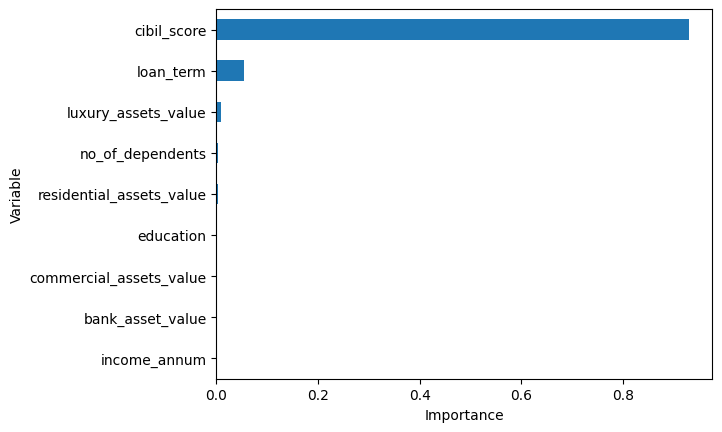

In [51]:
dtt_imp.plot(kind = 'barh',
             x = 'feature',
             y = 'importance',
             xlabel = 'Importance',
             ylabel = 'Variable',
             legend = False)

In [52]:
test_pred_dt = grid_dt.predict(test_X)

##Random Forest

In [53]:
pipe_RF = Pipeline(steps = [("preprocess", class_pp),
                            ("RF", RandomForestClassifier(random_state = 123, class_weight = 'balanced'))])
grid_RF = {'RF__n_estimators': [100, 200, 300],}

clf_RF = GridSearchCV(pipe_RF, grid_RF, scoring = 'accuracy', cv = 5)
clf_RF.fit(X = train_X, y = train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         'passthrough',
                                                                         ['no_of_dependents',
                                                                          'income_annum',
                                                                          'loan_term',
                                                                          'cibil_score',
                                                                          'residential_assets_value',
                                                                          'commercial_assets_value',
                                                                          'luxury_assets_value',
                                                                          'bank_asset_value']),
                                                                        ('nominal',
                                                                         Pipeline(steps=[('imputer_cats',
                                                                                          SimpleImputer(strategy='most_freque...
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('imputer_ords',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder_ords',
                                                                                          OrdinalEncoder(categories=[[' '
                                                                                                                      'Graduate',
                                                                                                                      ' '
                                                                                                                      'Not '
                                                                                                                      'Graduate']]))]),
                                                                         ['education'])],
                                                          verbose_feature_names_out=False)),
                                       ('RF',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=123))]),
             param_grid={'RF__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [54]:
print('Best Random Forest Model')
print('number of trees:', clf_RF.best_params_['RF__n_estimators'])
print('accuracy:', clf_RF.best_score_)

Best Random Forest Model
number of trees: 100
accuracy: 0.9625183016105417


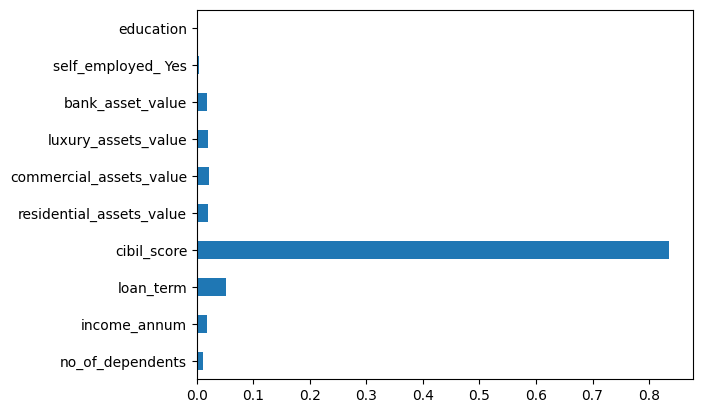

In [55]:
importances = pd.DataFrame({'feature': clf_RF.best_estimator_.named_steps['preprocess'].get_feature_names_out(),
                            'importance': clf_RF.best_estimator_.named_steps['RF'].feature_importances_})
ax = importances.plot(kind = 'barh', x = 'feature', legend = False)
ax.set_ylabel('')
plt.show()

In [56]:
rf_test_pred = clf_RF.predict(test_X)

##Logistic Regression

In [57]:
pipe = Pipeline(steps = [("preprocess", class_pp),
 ("logreg", LogisticRegression(solver = 'liblinear', random_state = 123, class_weight = 'balanced'))])
pipe.fit(train_X, train_y)
pd.DataFrame({'variable': pipe.named_steps['logreg'].feature_names_in_,
              'Coefficient (Log Odds)': np.transpose(pipe.named_steps['logreg'].coef_.squeeze()),
              'Coefficient (Odds)': np.transpose(np.exp(pipe.named_steps['logreg'].coef_.squeeze()))
                              })

,variable,Coefficient (Log Odds),Coefficient (Odds)
0,no_of_dependents,1.057625e-05,1.000011
1,income_annum,2.929040e-07,1.000000
2,loan_term,6.672485e-05,1.000067
3,cibil_score,-3.031548e-03,0.996973
4,residential_assets_value,1.984927e-09,1.000000
5,commercial_assets_value,-1.514772e-08,1.000000
6,luxury_assets_value,-5.559580e-09,1.000000
7,bank_asset_value,-5.153183e-09,1.000000
8,self_employed_ Yes,1.696602e-06,1.000002
9,education,1.991314e-06,1.000002


In [58]:
test_preds_lr = pipe.predict(X = test_X)

##ANN (MLP)

In [59]:
nums_trans = Pipeline(steps = [("imputer_nums", SimpleImputer(strategy = "median")), ("rescale_nums", StandardScaler())])
ords_trans = Pipeline(steps = [('imputer_ords', SimpleImputer(strategy = "most_frequent")),
        ("encoder_ords", OrdinalEncoder(categories ='auto'))])
noms_trans = Pipeline(steps = [("imputer_noms", SimpleImputer(strategy = "most_frequent")),
         ("encoder_nom", OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore"))])

pp = ColumnTransformer(transformers = [("numeric", nums_trans, numerical_var), ("nominal", noms_trans, nominal_var),
 ("ordinal", ords_trans, ordinal_var)], verbose_feature_names_out = False)

In [60]:
pipe = ImbPipeline(steps = [("preprocess", pp),
                             ("smote", SMOTE(random_state = 123)),
                              ("MLP", MLPClassifier(random_state = 123, max_iter = 3000))])
pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer_nums',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('rescale_nums',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('nominal',
                                                  Pipelin...
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['self_employed']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer_ords',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder_ords',
                                                                   OrdinalEncoder())]),
                                                  ['education'])],
                                   verbose_feature_names_out=False)),
                ('smote', SMOTE(random_state=123)),
                ('MLP', MLPClassifier(max_iter=3000, random_state=123))])

In [61]:
param_grid_mlp = dict(MLP__hidden_layer_sizes = [(45, 35, 25), (35, 25, 15),
                                                 (45, 35), (35, 25)])
param_grid_mlp

{'MLP__hidden_layer_sizes': [(45, 35, 25), (35, 25, 15), (45, 35), (35, 25)]}

In [62]:
grid_mlp = GridSearchCV(pipe, param_grid =  param_grid_mlp, cv = 5, error_score='raise')
grid_mlp.fit(X = train_X, y = train_y)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer_nums',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('rescale_nums',
                                                                                          StandardScaler())]),
                                                                         ['no_of_dependents',
                                                                          'income_annum',
                                                                          'loan_term',
                                                                          'cibil_score',
                                                                          'residential_assets_value',
                                                                          'commercial_assets_value',
                                                                          'luxury_asset...
                                                                         ['self_employed']),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('imputer_ords',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder_ords',
                                                                                          OrdinalEncoder())]),
                                                                         ['education'])],
                                                          verbose_feature_names_out=False)),
                                       ('smote', SMOTE(random_state=123)),
                                       ('MLP',
                                        MLPClassifier(max_iter=3000,
                                                      random_state=123))]),
             param_grid={'MLP__hidden_layer_sizes': [(45, 35, 25), (35, 25, 15),
                                                     (45, 35), (35, 25)]})

In [63]:
print('Number of Hidden nodes:', grid_mlp.best_params_['MLP__hidden_layer_sizes'])
print('Accuracy:', grid_mlp.best_score_)

Number of Hidden nodes: (35, 25)
Accuracy: 0.9458272327964862


In [64]:
test_pred_mlp = grid_mlp.predict(test_X)

## 2.2 Model Evaluation (15)

**2.2 A (8) Evaluate the performance of all models.**

In [65]:
print("Decision Tree")
print(classification_report(test_y, test_pred_dt))
print("Random Forest")
print(classification_report(test_y, rf_test_pred))
print("Logistic Regression")
print(classification_report(test_y, test_preds_lr))
print("MLP")
print(classification_report(test_y, test_pred_mlp))

Decision Tree
              precision    recall  f1-score   support

    Approved       0.98      0.94      0.96       504
    Rejected       0.92      0.97      0.94       350

    accuracy                           0.95       854
   macro avg       0.95      0.96      0.95       854
weighted avg       0.95      0.95      0.95       854

Random Forest
              precision    recall  f1-score   support

    Approved       0.94      0.99      0.96       504
    Rejected       0.98      0.91      0.94       350

    accuracy                           0.95       854
   macro avg       0.96      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854

Logistic Regression
              precision    recall  f1-score   support

    Approved       0.71      0.82      0.76       504
    Rejected       0.66      0.52      0.58       350

    accuracy                           0.70       854
   macro avg       0.69      0.67      0.67       854
weighted avg       0.69   

Decision Tree
Random Forest
Logistic Regression
MLP


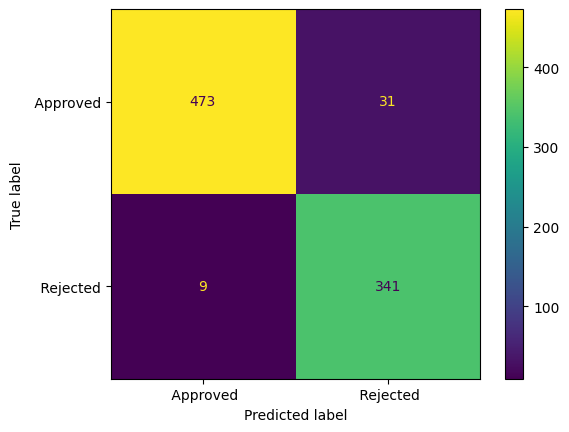

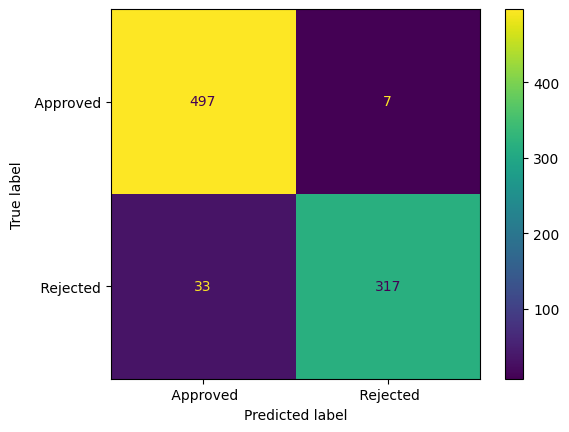

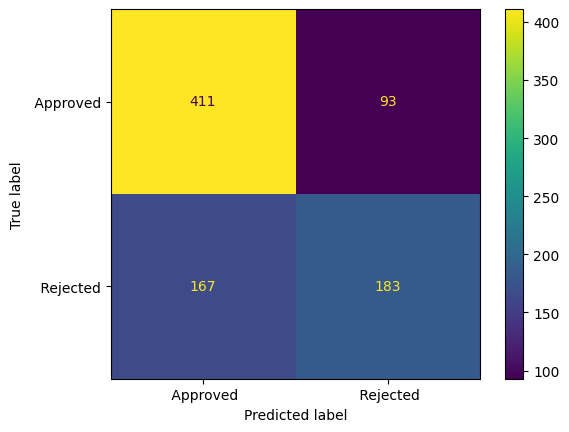

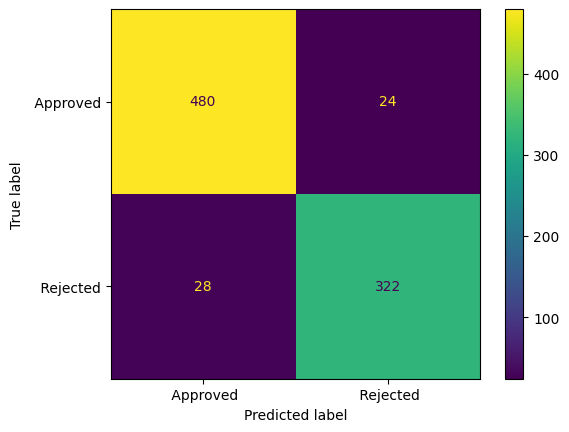

In [66]:
print("Decision Tree")
ConfusionMatrixDisplay.from_predictions(test_y, test_pred_dt)
print("Random Forest")
ConfusionMatrixDisplay.from_predictions(test_y, rf_test_pred)
print("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(test_y, test_preds_lr)
print("MLP")
ConfusionMatrixDisplay.from_predictions(test_y, test_pred_mlp)

**2.2 B (7) Based on your output in 2.2A, discuss and compare the performance for each of the classification models. Which model is preferred? Why? Explain.**

Hence Based on the performance of all 4 models. The top 2 models are Decison Tree and Random forest with 95% accuracy overall. On second, in ANN(MLP) and logistic regression has significantly low performed. Also, in terms of precision both the top models have significant percentages. However, The balance of random forest is slightly better as it achieves 99% recall with 94% precision for approved cases and 91% recall with 98% precision for rejection. These numbers makes Random Forest as first preference among 4 of them. As it will miss very few qualified applicants with 99% recall and on the other hand will notify 98% of not qualified with 91% recall. Giving us very low or negligible false negatives or positives.

However, if we want a detailed reasoning structure while taking the decsion, we can also opt Decision Tree as it will also identify the situations equally good.

## 2.3 Discussion & Conclusion (10)

**2.3 (10) Briefly summarize the problem statement and data. Then, discuss your analysis and findings in depth. Within the context of the business problem and your analysis results (regression and classification), provide business recommendations. Be sure to discuss any limitations, constraints, or ethical concerns that could impact the implementation of the recommended solution.**

Summarizing our problem statement, the goal was to achieve a model to automate the laon approvals process and bring efficieny in the process to reduce risk of defaulters and making wrong decisions for qualified clients and vice versa. The dataset provided us significant real life features involved in the process, through which we came up with our models.

Based on the analysis, the optimal approach would be to keep the models in two step modelling solution. For the intial approval or rejection decison, the Random Forest is recomended because of its superior balance of precision and recall can significantly help to approve or disapprove the candidate. Following the suitable loan amount can be decided through Linear regression model, which will provide a detail predictions based on significant variables.
However, there are some limitations to these models based on which we do recomend to keep human intervention in the loop and should not leave it totally on the automated models. Following are the limitations:
*   Assumptions Violations and Insignificance of some predictors in linear regression.
*   Black Box nature of Random forest.
To over come the black box nature of random forest if they need a more interpretable model we can opt Decision Tree as it gives detailed structure in if else format.
*   Computing power (MLP classifier shows delay)
* Only two significant predictors for numerical target, which makes model baseline predictive model.
*   Outliers in data.

Hence, The goal has been achieved with this two step loan approval model.






=======================================